<a href="https://colab.research.google.com/github/mic006016/yolo-pedestrian-safety/blob/main/YOLOv7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128


In [ ]:
# GPU 사용 체크
is_cuda = False
if torch.cuda.is_available():
  is_cuda = True

print("CUDA 사용 가능 여부:", torch.cuda.is_available())

CUDA 사용 가능 여부: True


In [ ]:
# PASCAL VOC Dataset 다운로드 및 압축 풀기
!pip install gdown
!gdown 1w_WBizEt2e_u6T9iY-hkwA-fIVsJktbB
!tar -xf VOCtrainval_11-May-2012.tar
!rm VOCtrainval_11-May-2012.tar

Downloading...
From (original): https://drive.google.com/uc?id=1w_WBizEt2e_u6T9iY-hkwA-fIVsJktbB
From (redirected): https://drive.google.com/uc?id=1w_WBizEt2e_u6T9iY-hkwA-fIVsJktbB&confirm=t&uuid=f59f9292-e142-44f5-9924-9e016fd2abbd
To: /content/VOCtrainval_11-May-2012.tar
100% 2.00G/2.00G [00:43<00:00, 46.4MB/s]


In [ ]:
# Pascal VOC 데이터셋의 클래스 리스트가 있는 파일 생성
classes = ["aeroplane\n", "bicycle\n", "bird\n", "boat\n", "bottle\n",
           "bus\n", "car\n", "cat\n", "chair\n", "cow\n", "diningtable\n",
           "dog\n", "horse\n", "motorbike\n", "person\n", "pottedplant\n",
           "sheep\n", "sofa\n", "train\n", "tvmonitor"]
with open("vocnames.txt", 'w') as f:
    f.writelines(classes)

In [ ]:
# convert2Yolo 저장소를 활용해 xml 파일을 txt 파일로 변환
!git clone https://github.com/ssaru/convert2Yolo.git
!cd convert2Yolo && python3 example.py --datasets VOC \
--img_path ../VOCdevkit/VOC2012/JPEGImages/ \
--label ../VOCdevkit/VOC2012/Annotations/ \
--convert_output_path ../VOCdevkit/VOC2012/JPEGImages/ \
--img_type ".jpg" \
--manifest_path ../ \
--cls_list_file ../vocnames.txt

Cloning into 'convert2Yolo'...
remote: Enumerating objects: 215, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 215 (delta 38), reused 35 (delta 35), pack-reused 172 (from 1)
Receiving objects: 100% (215/215), 994.67 KiB | 49.73 MiB/s, done.
Resolving deltas: 100% (95/95), done.

VOC Parsing:   |████████████████████████████████████████| 100.0% (17125/17125)  Complete


YOLO Generating:|████████████████████████████████████████| 100.0% (17125/17125)  Complete


YOLO Saving:   |████████████████████████████████████████| 100.0% (17125/17125)  Complete



In [ ]:
# 훈련 데이터와 검증 데이터 분리
import os
import shutil
from tqdm import tqdm
data_root = "/content/VOCData"
val_root = os.path.join(data_root, "val")
train_root = os.path.join(data_root, "train")
os.makedirs(val_root, exist_ok=True)
os.makedirs(train_root, exist_ok=True)

with open("/content/manifest.txt") as f:
    files = f.readlines()

for idx, img_path in tqdm(enumerate(files)):
    img_src = img_path.split('\n')[0]
    txt_src = os.path.splitext(img_src)[0] + ".txt"
    img_name = os.path.split(img_src)[-1]
    text_name = os.path.split(txt_src)[-1]
    if idx % 10 < 3:
        img_dst = os.path.join(val_root, img_name)
        text_dst = os.path.join(val_root, text_name)
    else:
        img_dst = os.path.join(train_root, img_name)
        text_dst = os.path.join(train_root, text_name)
    shutil.copy2(img_src, img_dst)
    shutil.copy2(txt_src, text_dst)

17125it [00:04, 3937.66it/s]


YOLOv7 환경 구축

In [ ]:
# 1. YOLOv7  클론
!git clone https://github.com/WongKinYiu/yolov7

# 2. yolov7 폴더로 이동
%cd yolov7

# 3. 마법의 명령어: requirements.txt 파일 안의 버전 기호(==, >=, <=)들을 싹 지워버림
!sed -i 's/[>=<].*//g' requirements.txt

# 4. 버전 제한이 풀린 상태로 쾌적하게 패키지 설치
!pip install -r requirements.txt

Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.29 MiB | 15.05 MiB/s, done.
Resolving deltas: 100% (511/511), done.
/content/yolov7
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.1 MB/s eta 0:00:00


In [ ]:
# YOLOv7 폴더 위치인지 확인
%cd /content/yolov7

# 파이토치 보안 검사 해제 코드 자동 주입
!sed -i 's/ckpt = torch.load(w, map_location=map_location)/ckpt = torch.load(w, map_location=map_location, weights_only=False)/g' models/experimental.py

/content/yolov7


Namespace(weights=['yolov7-tiny.pt'], source='inference/images', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152.75MB)

Fusing layers... 
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 200 layers, 6219709 parameters, 229245 gradients, 13.7 GFLOPS
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

4 persons, 1 bus, Done. (4.6ms) Inference, (75.0ms) NMS
 The image with the result is saved in: r

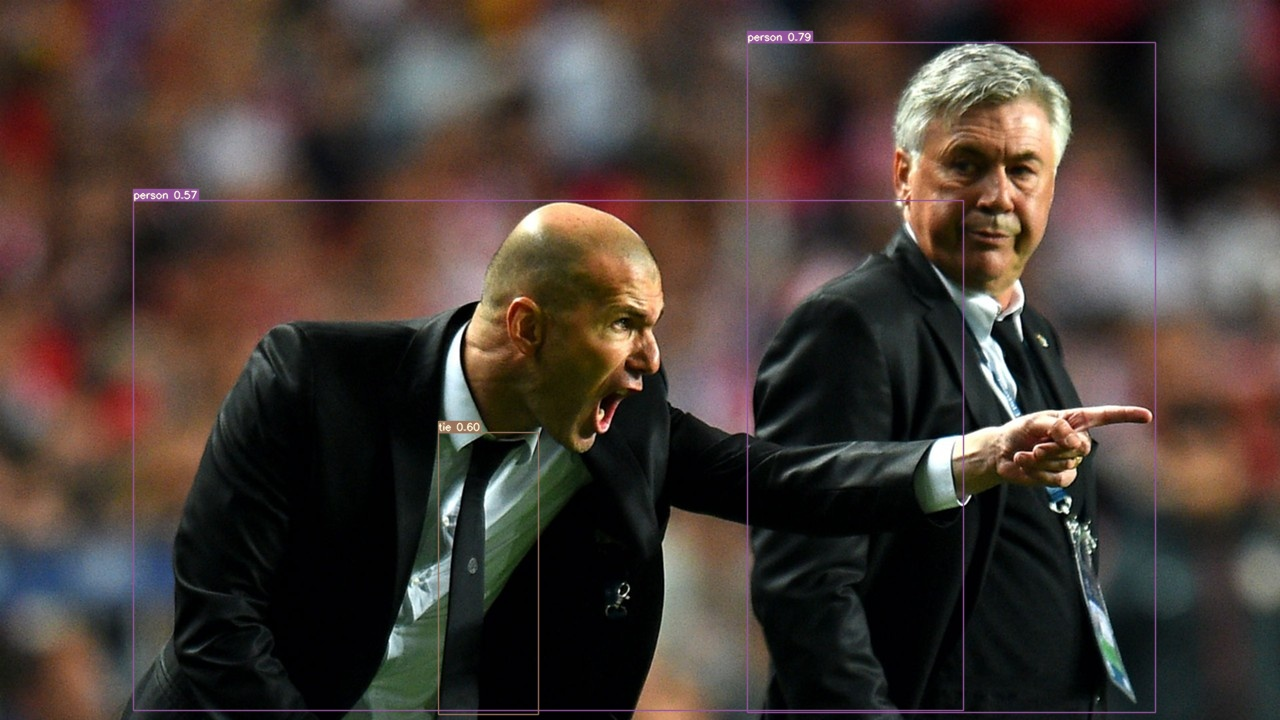

In [ ]:
# 테스트
!python detect.py --weights yolov7-tiny.pt --img 640 --conf 0.25 --source inference/images
import cv2
from google.colab.patches import cv2_imshow
cv2_imshow(cv2.imread('runs/detect/exp/zidane.jpg'))

In [ ]:
# 폴더 경로를 입력하여 VOC 데이터셋을 훈련하기 위한 yaml파일 생성
text_lines = '''
train:  /content/VOCData/train
val:  /content/VOCData/val

# number of classes
nc: 20

# class names
names: [ 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
         'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',
         'dog', 'horse', 'motorbike', 'person', 'pottedplant',
         'sheep', 'sofa', 'train', 'tvmonitor' ]
'''
with open("/content/yolov7/vocdata.yaml", 'w') as f:
    f.write(text_lines)

In [ ]:
!pwd

/content/yolov7


In [ ]:
# train.py 파일 내의 보안 검사 해제 코드 자동 주입
!sed -i 's/torch.load(weights, map_location=device)/torch.load(weights, map_location=device, weights_only=False)/g' train.py

# utils/general.py 파일 내의 청소 단계 보안 검사 해제
!sed -i "s/torch.load(f, map_location=torch.device('cpu'))/torch.load(f, map_location=torch.device('cpu'), weights_only=False)/g" utils/general.py

In [ ]:
# 훈련 수행
!python train.py --img 320 --batch 8 --epochs 20 --data vocdata.yaml --weights yolov7-tiny.pt --cache

2026-06-12 13:11:34.753418: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-12 13:11:34.822977: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
YOLOR 🚀 v0.1-128-ga207844 torch 2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152.75MB)

Namespace(weights='yolov7-tiny.pt', cfg='', data='vocdata.yaml', hyp='data/hyp.scratch.p5.yaml', epochs=20, batch_size=8, img_size=[320, 320], rect=False, resume=False, nosave=False, notest=False, noautoanchor=False, evolve=False, bucket='', cache_images=True, image_weights=False, dev

In [ ]:
# weight 파일 다운로드
from google.colab import files
files.download('/content/yolov7/runs/train/exp/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>